# Poster Figures

Four charts for the poster presentation:

1. **Pioneer × Synthesis 2×2** — helpfulness rate by information quadrant  
2. **Ablation curve** — cumulative AUC as feature groups are added  
3. **Feature group importance** — share of model weight by group  
4. **Language normalisation effect** — raw vs. z-scored word count distributions  

All figures are saved to `figures/` at 300 dpi.

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Output directory
FIG_DIR = os.path.join(os.path.dirname(os.getcwd()), '..', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Consistent style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

# Dark orange – purple palette
PURPLE       = '#6B21A8'
DARK_ORANGE  = '#C2410C'
MID_PURPLE   = '#9333EA'
MID_ORANGE   = '#EA580C'
LIGHT_PURPLE = '#D8B4FE'
LIGHT_ORANGE = '#FED7AA'
GREY         = '#4B5563'

print('Output directory:', os.path.abspath(FIG_DIR))

Output directory: /Users/ameliasoare/Documents/MSc. Data Science/BigDataProject/figures


---
## 1. Pioneer × Synthesis 2×2

Splits the training set into four quadrants using the median of `product_tfidf_novelty` (Pioneer) and `product_tfidf_synthesis` (Synthesis), then measures the helpful rate in each quadrant.

In [8]:
import glob as _glob
_ml_files = sorted(_glob.glob(os.path.join(
    os.path.dirname(os.getcwd()), '..', 'data', 'gold', 'ml_features_load_date=*.parquet'
)))
DATA_PATH = _ml_files[-1]  # latest partition
print('Loading:', DATA_PATH)

df = pd.read_parquet(DATA_PATH)
df['label'] = df['label'].astype(str).map({'True': True, 'False': False})

# Use training split only to avoid test leakage
train = df[df['dataset_split'] == 'train'].copy()

pioneer_med   = train['product_tfidf_novelty'].median()
synthesis_med = train['product_tfidf_synthesis'].median()

def quadrant(row):
    hi_p = row['product_tfidf_novelty']  >= pioneer_med
    hi_s = row['product_tfidf_synthesis'] >= synthesis_med
    if hi_p and hi_s:     return 'Validates'
    if hi_p and not hi_s: return 'Bold Claim'
    if not hi_p and hi_s: return 'Echo'
    return 'Outlier / Noise'

train['quadrant'] = train.apply(quadrant, axis=1)

quad_stats = (
    train.groupby('quadrant')['label']
    .agg(helpful_rate='mean', n='count')
    .reset_index()
)
print(quad_stats)
print(f'\nPioneer median:   {pioneer_med:.3f}')
print(f'Synthesis median: {synthesis_med:.3f}')
print(f'Baseline helpful rate: {train["label"].mean():.1%}')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/ameliasoare/Documents/MSc. Data Science/BigDataProject/src/../data/gold/ml_features_load_date=2026-03-18.parquet'

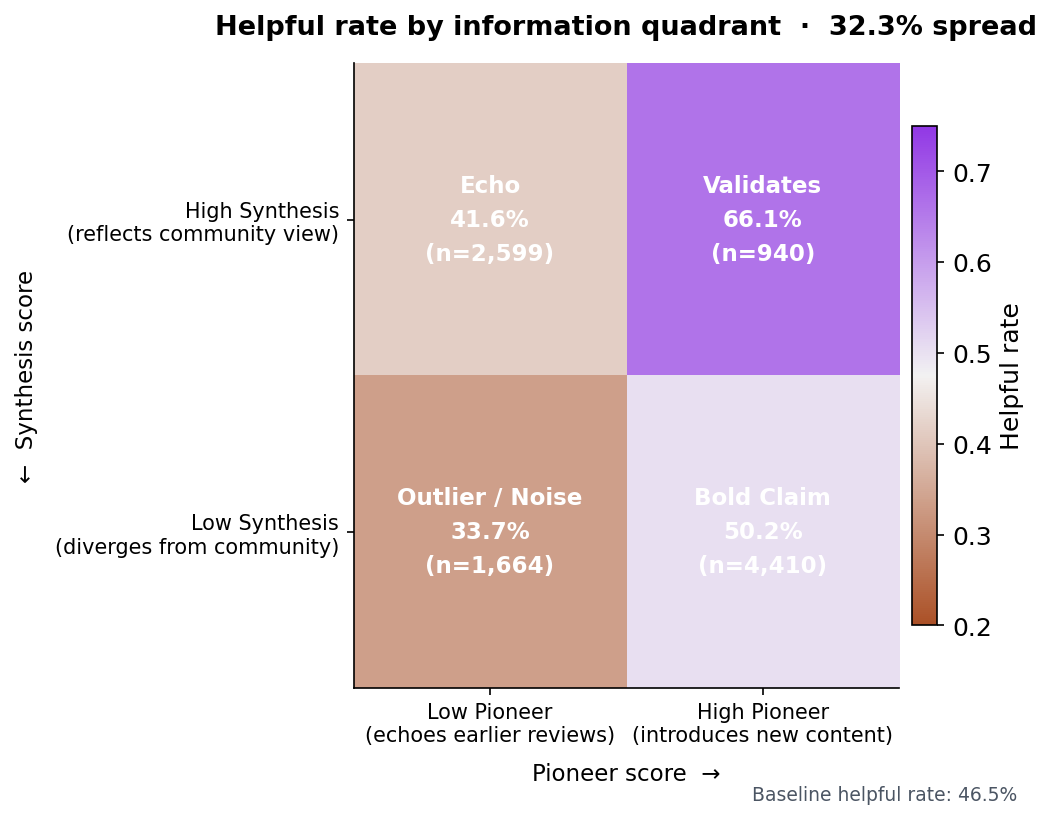

Saved pioneer_synthesis_2x2.png


In [ ]:
# Layout: rows = Synthesis (High top, Low bottom), cols = Pioneer (Low left, High right)
quad_lookup = quad_stats.set_index('quadrant')

grid_labels = [
    ['Echo',            'Validates'    ],  # High Synthesis row
    ['Outlier / Noise', 'Bold Claim'   ],  # Low Synthesis row
]

rates  = np.array([[quad_lookup.loc[q, 'helpful_rate'] for q in row] for row in grid_labels])
counts = np.array([[quad_lookup.loc[q, 'n']            for q in row] for row in grid_labels])

baseline = train['label'].mean()
spread   = rates.max() - rates.min()

fig, ax = plt.subplots(figsize=(7, 5.5))

# Orange (low) → purple (high) diverging colormap
cmap = sns.diverging_palette(25, 280, s=85, l=45, as_cmap=True)
im = ax.imshow(rates, cmap=cmap, vmin=0.2, vmax=0.75, aspect='auto')

# Cell annotations
for r in range(2):
    for c in range(2):
        name = grid_labels[r][c]
        rate = rates[r, c]
        n    = counts[r, c]
        text_color = 'white'
        ax.text(c, r, f'{name}\n{rate:.1%}\n(n={n:,})',
                ha='center', va='center', fontsize=11,
                color=text_color, fontweight='bold', linespacing=1.6)

ax.set_xticks([0, 1])
ax.set_xticklabels(
    ['Low Pioneer\n(echoes earlier reviews)', 'High Pioneer\n(introduces new content)'],
    fontsize=10
)
ax.set_yticks([0, 1])
ax.set_yticklabels(
    ['High Synthesis\n(reflects community view)', 'Low Synthesis\n(diverges from community)'],
    fontsize=10
)
ax.xaxis.set_ticks_position('bottom')
ax.set_xlabel('Pioneer score  →', fontsize=11, labelpad=8)
ax.set_ylabel('←  Synthesis score', fontsize=11, labelpad=8)
ax.set_title(
    f'Helpful rate by information quadrant  ·  {spread:.1%} spread',
    fontsize=13, pad=14, fontweight='bold'
)

fig.text(0.98, 0.01, f'Baseline helpful rate: {baseline:.1%}',
         ha='right', va='bottom', fontsize=9, color=GREY)

plt.colorbar(im, ax=ax, label='Helpful rate', shrink=0.8, pad=0.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pioneer_synthesis_2x2.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved pioneer_synthesis_2x2.png')

---
## 2. Ablation Curve

Cumulative holdout AUC as feature groups are added one at a time.  
Results from the ablation run in `ml_model_v1.ipynb`.

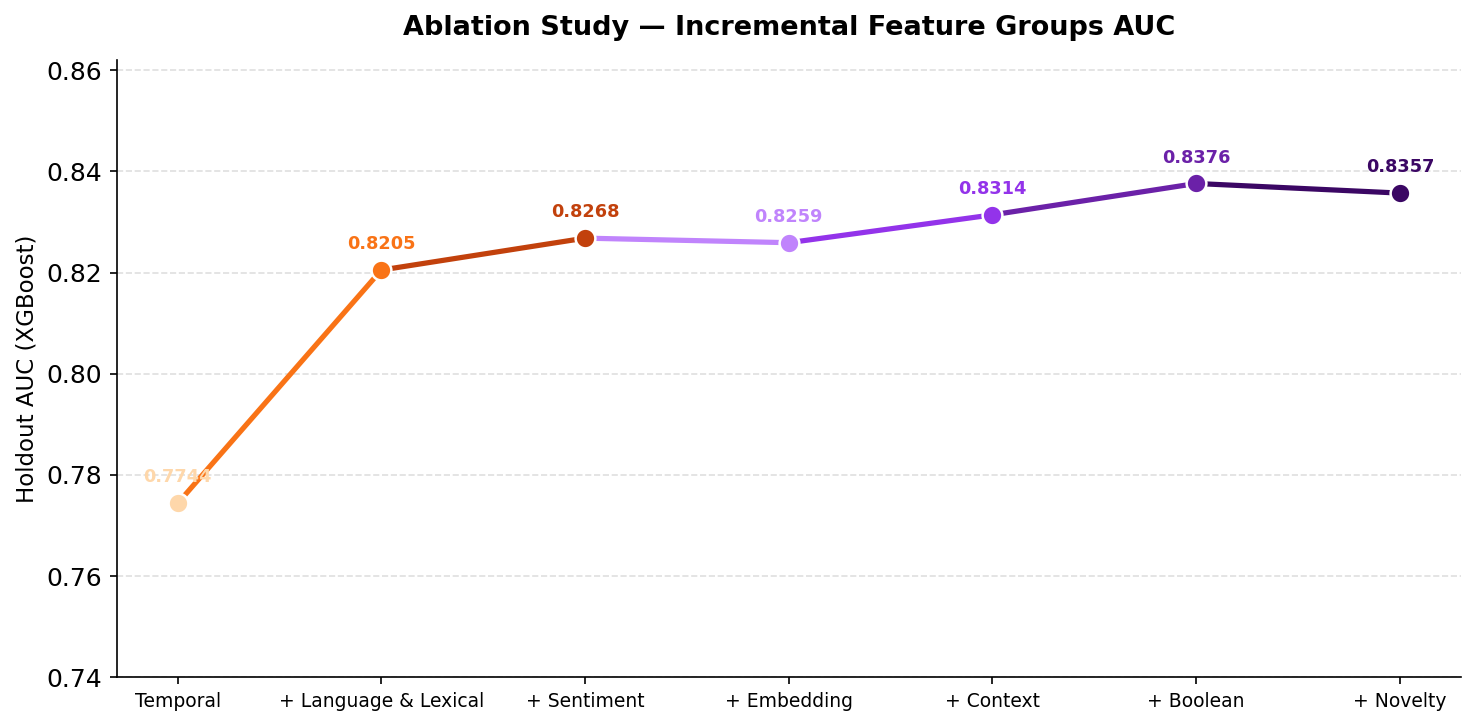

Saved ablation_curve.png


In [9]:
ablation = pd.DataFrame([
    {'group': 'Temporal', 'auc': 0.7744},
    {'group': '+ Language & Lexical', 'auc': 0.8205},
    {'group': '+ Sentiment', 'auc': 0.8268},
    {'group': '+ Embedding', 'auc': 0.8259},
    {'group': '+ Context', 'auc': 0.8314},
    {'group': '+ Boolean', 'auc': 0.8376},
    {'group': '+ Novelty', 'auc': 0.8357},
])

palette = [
    '#FED7AA',  # Temporal             
    '#F97316',  # + Language & Lexical 
    '#C2410C',  # + Sentiment          
    '#C084FC',  # + Embedding          
    '#9333EA',  # + Context           
    '#6B21A8',  # + Boolean           
    '#3B0764',  # + Novelty            
]

fig, ax = plt.subplots(figsize=(10, 5))

for i in range(len(ablation)):
    if i > 0:
        ax.plot([i - 1, i], [ablation['auc'].iloc[i - 1], ablation['auc'].iloc[i]],
                color=palette[i], linewidth=2.5, zorder=2)
    ax.scatter(i, ablation['auc'].iloc[i], color=palette[i], s=90, zorder=3,
               edgecolors='white', linewidths=1.2)
    ax.annotate(f"{ablation['auc'].iloc[i]:.4f}",
                (i, ablation['auc'].iloc[i]),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=8.5, color=palette[i], fontweight='bold')

ax.set_xticks(ablation.index)
ax.set_xticklabels(
    ablation['group'].tolist(),
    fontsize=9
)
ax.set_ylabel('Holdout AUC (XGBoost)', fontsize=11)
ax.set_title('Ablation Study — Incremental Feature Groups AUC', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0.74, 0.862)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'ablation_curve.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved ablation_curve.png')

---
## 3. Feature Group Importance

Aggregated XGBoost feature importance by group (impurity-based, from `ml_model_v1.ipynb`).

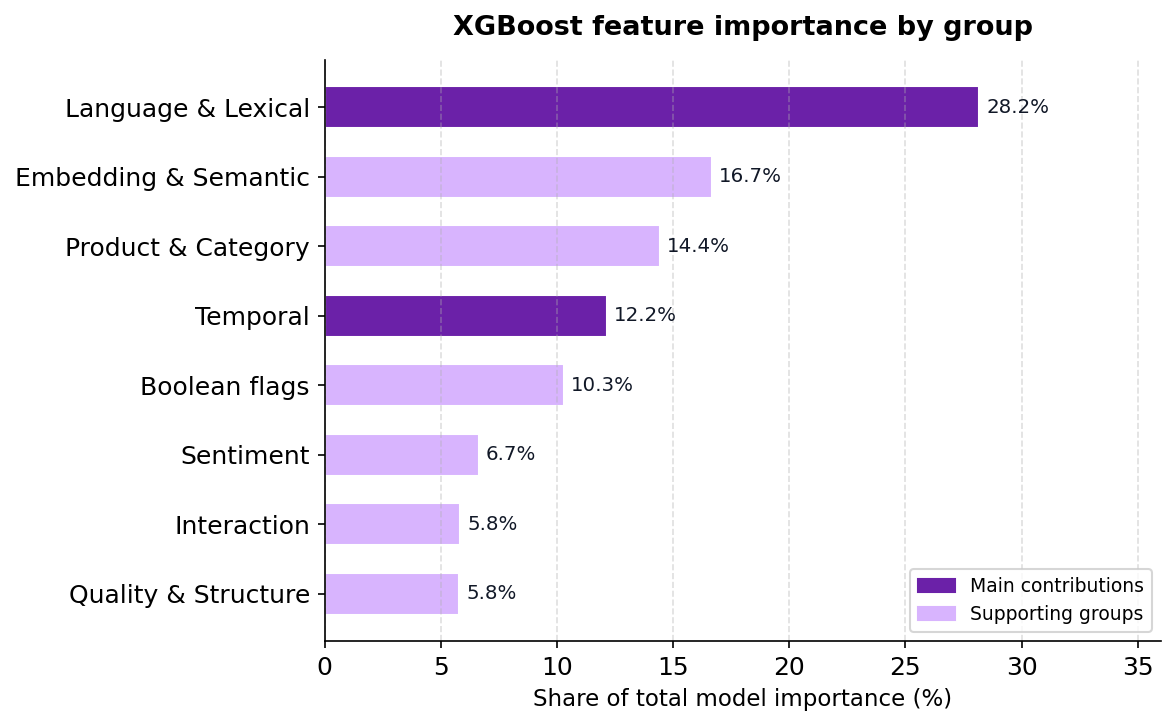

Saved feature_group_importance.png


In [10]:
importance = pd.DataFrame([
    {'group': 'Language & Lexical',   'importance': 0.2818},
    {'group': 'Embedding & Semantic', 'importance': 0.1666},
    {'group': 'Product & Category',   'importance': 0.1442},
    {'group': 'Temporal',             'importance': 0.1216},
    {'group': 'Boolean flags',        'importance': 0.1030},
    {'group': 'Sentiment',            'importance': 0.0665},
    {'group': 'Interaction',          'importance': 0.0583},
    {'group': 'Quality & Structure',  'importance': 0.0580},
]).sort_values('importance')

# Highlight the two groups tied to main poster contributions
highlight = {'Language & Lexical', 'Temporal'}
colors = [PURPLE if g in highlight else LIGHT_PURPLE for g in importance['group']]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(importance['group'], importance['importance'] * 100,
               color=colors, height=0.6, edgecolor='white')

for bar, val in zip(bars, importance['importance']):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1%}', va='center', fontsize=9.5, color='#111827')

ax.set_xlabel('Share of total model importance (%)', fontsize=11)
ax.set_title('XGBoost feature importance by group', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 36)
ax.grid(axis='x', linestyle='--', alpha=0.4)

legend_patches = [
    mpatches.Patch(color=PURPLE,       label='Main contributions'),
    mpatches.Patch(color=LIGHT_PURPLE, label='Supporting groups'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'feature_group_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved feature_group_importance.png')

---
## 4. Cross-Lingual Normalisation — The Bias Problem

Three charts that together tell the full story of why normalisation is needed and what it does:

- **4a** — Mean word count per language: shows the different baselines across languages
- **4b** — Helpful rate by shared word count bin per language: shows that the same raw word count predicts helpfulness differently depending on language
- **4c** — Raw vs. normalised distributions: shows that z-scoring aligns the distributions

In [11]:
# --- 4a: Mean word count per language (the different baselines) ---
main_langs  = ['en', 'fr', 'de', 'hu']
lang_labels = {'en': 'English', 'fr': 'French', 'de': 'German', 'hu': 'Hungarian'}
lang_colors = {
    'en': DARK_ORANGE,
    'fr': MID_ORANGE,
    'de': MID_PURPLE,
    'hu': PURPLE,
}

subset = train[train['detected_language'].isin(main_langs)].copy()
subset['raw_word_count'] = np.expm1(subset['log_body_word_count'])

lang_stats = (
    subset.groupby('detected_language')['raw_word_count']
    .agg(mean='mean', median='median')
    .loc[main_langs]
)

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    [lang_labels[l] for l in main_langs],
    lang_stats['mean'],
    color=[lang_colors[l] for l in main_langs],
    width=0.5, edgecolor='white'
)
ax.bar(
    [lang_labels[l] for l in main_langs],
    lang_stats['median'],
    color=[lang_colors[l] for l in main_langs],
    width=0.5, alpha=0.4, edgecolor='white',
    label='Median'
)

for bar, val in zip(bars, lang_stats['mean']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5,
            f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Word count', fontsize=11)
ax.set_title('Review length by language', fontsize=13, fontweight='bold', pad=10)
ax.set_ylim(0, 145)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lang_word_count_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved lang_word_count_baseline.png')

NameError: name 'train' is not defined

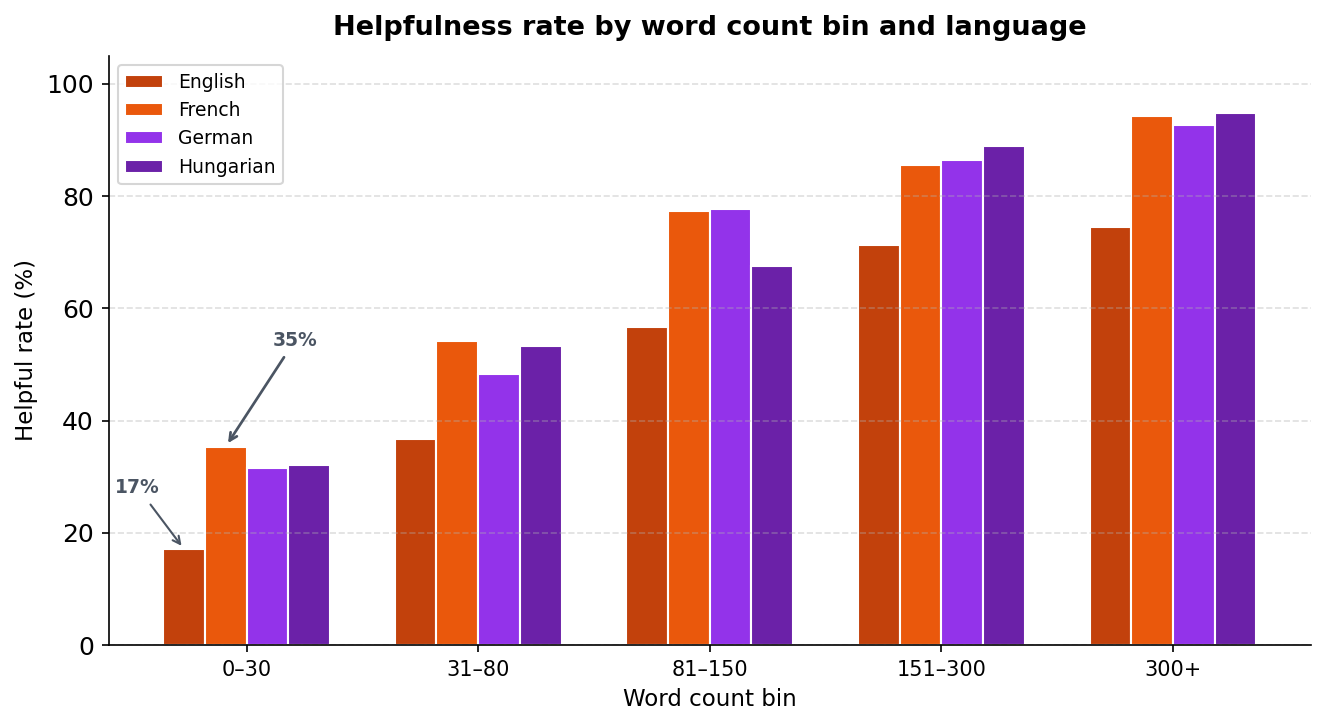

Saved lang_helpful_rate_by_bin.png


In [ ]:
# --- 4b: Helpful rate by shared word count bin per language ---
bins   = [0, 30, 80, 150, 300, 5000]
labels = ['0–30', '31–80', '81–150', '151–300', '300+']

subset['wc_bin'] = pd.cut(subset['raw_word_count'], bins=bins, labels=labels)

helpful_by_bin = (
    subset.groupby(['wc_bin', 'detected_language'], observed=True)['label']
    .mean()
    .unstack('detected_language')
    [main_langs]
)

x = np.arange(len(labels))
width = 0.18

fig, ax = plt.subplots(figsize=(9, 5))

bar_positions = {}
for i, lang in enumerate(main_langs):
    offset = (i - 1.5) * width
    ax.bar(
        x + offset,
        helpful_by_bin[lang] * 100,
        width=width,
        label=lang_labels[lang],
        color=lang_colors[lang],
        edgecolor='white'
    )
    bar_positions[lang] = x[0] + offset

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_xlabel('Word count bin', fontsize=11)
ax.set_ylabel('Helpful rate (%)', fontsize=11)
ax.set_title('Helpfulness rate by word count bin and language', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=9, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_ylim(0, 105)

en_rate = helpful_by_bin.loc['0–30', 'en'] * 100
fr_rate = helpful_by_bin.loc['0–30', 'fr'] * 100

# French: label above-right, arrow pointing down-left to bar top
ax.annotate(
    f'{fr_rate:.0f}%',
    xy=(bar_positions['fr'], fr_rate),
    xytext=(bar_positions['fr'] + 0.30, fr_rate + 18),
    fontsize=9, color=GREY, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=GREY, lw=1.3),
    ha='center'
)
# English: label above-left, arrow pointing down-right to bar top
ax.annotate(
    f'{en_rate:.0f}%',
    xy=(bar_positions['en'], en_rate),
    xytext=(bar_positions['en'] - 0.20, en_rate + 10),
    fontsize=9, color=GREY, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=GREY, lw=1.0),
    ha='center'
)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lang_helpful_rate_by_bin.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved lang_helpful_rate_by_bin.png')

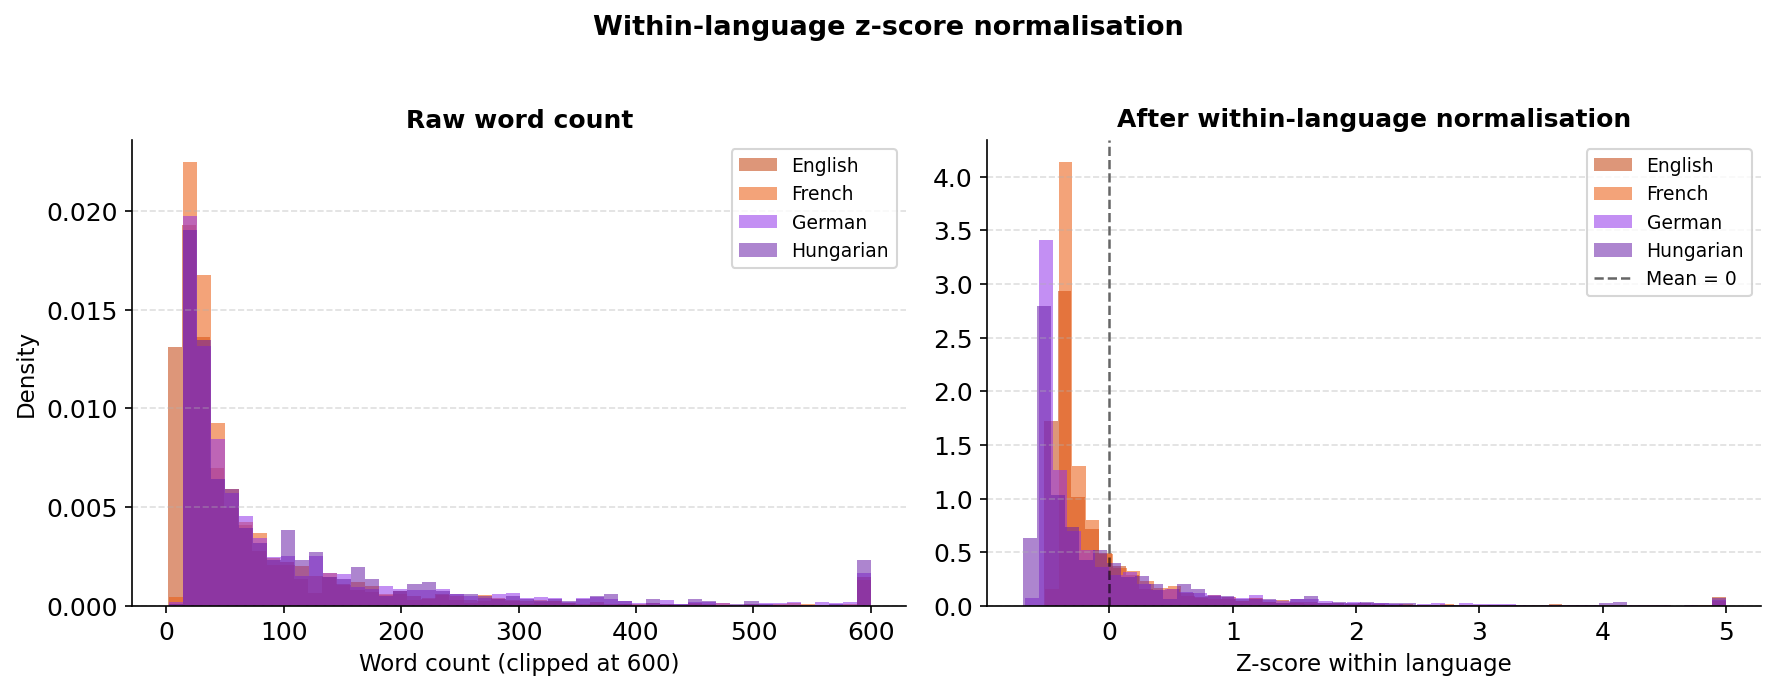

Saved lang_normalisation_distributions.png


In [ ]:
# --- 4c: Raw vs normalised distributions per language ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for lang in main_langs:
    d = subset[subset['detected_language'] == lang]['raw_word_count']
    axes[0].hist(d.clip(upper=600), bins=50, alpha=0.55,
                 label=lang_labels[lang], color=lang_colors[lang], density=True)

axes[0].set_xlabel('Word count (clipped at 600)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Raw word count', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for lang in main_langs:
    d = subset[subset['detected_language'] == lang]['body_lang_zscore']
    axes[1].hist(d.clip(-3, 5), bins=50, alpha=0.55,
                 label=lang_labels[lang], color=lang_colors[lang], density=True)

axes[1].set_xlabel('Z-score within language', fontsize=11)
axes[1].set_title('After within-language normalisation', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.6, label='Mean = 0')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Within-language z-score normalisation', fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'lang_normalisation_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved lang_normalisation_distributions.png')

---
## 5. Model Performance vs Baseline

Two charts for the Analysis section:

- **5a** — AUC comparison across models vs TA baseline
- **5b** — CV vs holdout AUC per model (no overfitting evidence)

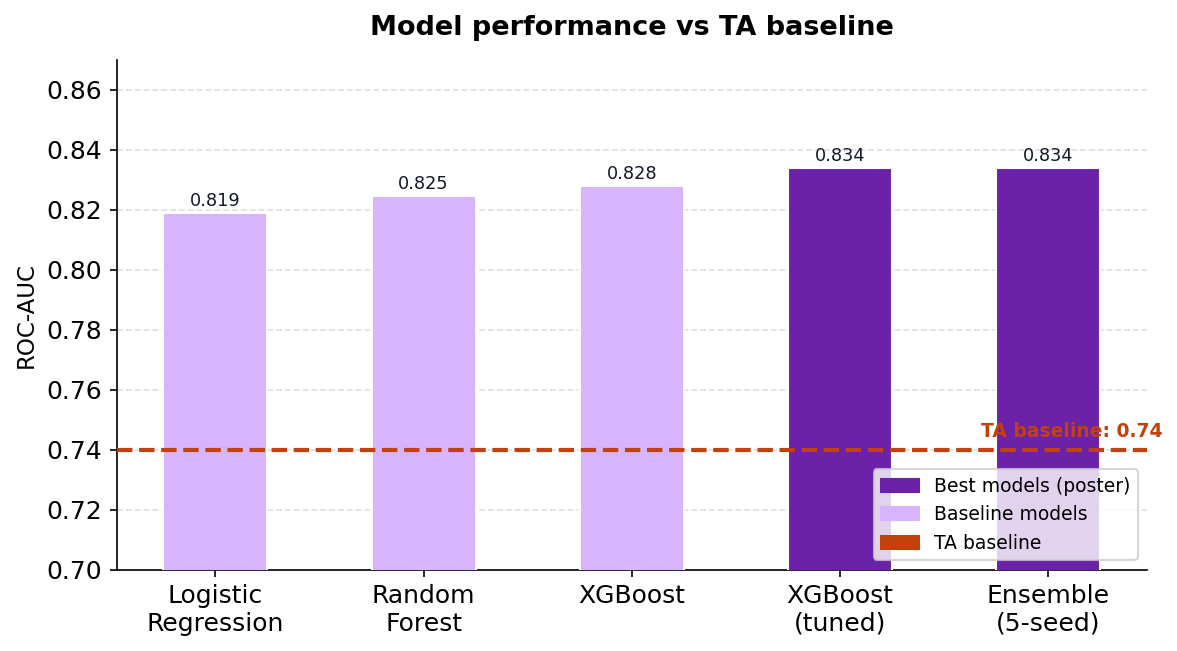

Saved model_performance_vs_baseline.png


In [12]:
# --- 5a: AUC comparison — our models vs TA baseline ---
TA_BASELINE = 0.74

models_auc = [
    ('Logistic\nRegression', 0.8191),
    ('Random\nForest',       0.8245),
    ('XGBoost',              0.8279),
    ('XGBoost\n(tuned)',     0.8340),
    ('Ensemble\n(5-seed)',   0.8341),
]

labels = [m[0] for m in models_auc]
values = [m[1] for m in models_auc]

# Colour tuned/ensemble purple, others light purple, baseline grey
bar_colors = [LIGHT_PURPLE, LIGHT_PURPLE, LIGHT_PURPLE, PURPLE, PURPLE]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(labels, values, color=bar_colors, width=0.5, edgecolor='white',
              zorder=3)

# TA baseline line
ax.axhline(TA_BASELINE, color=DARK_ORANGE, linewidth=2, linestyle='--', zorder=4)
ax.text(len(labels) - 0.45, TA_BASELINE + 0.003,
        f'TA baseline: {TA_BASELINE:.2f}',
        color=DARK_ORANGE, fontsize=9, fontweight='bold', va='bottom', ha='right')

# Value labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5, color='#111827')

ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_ylim(0.70, 0.87)
ax.set_title('Model performance vs TA baseline', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

legend_patches = [
    mpatches.Patch(color=PURPLE,       label='Best models (poster)'),
    mpatches.Patch(color=LIGHT_PURPLE, label='Baseline models'),
    mpatches.Patch(color=DARK_ORANGE,  label='TA baseline'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'model_performance_vs_baseline.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved model_performance_vs_baseline.png')

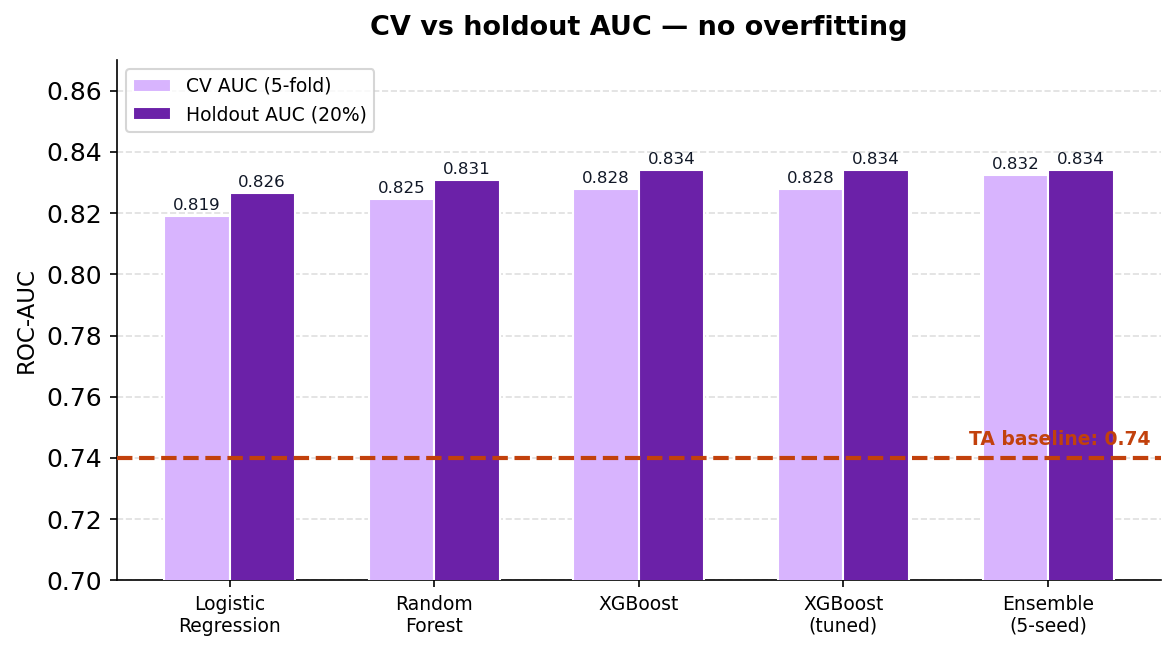

Saved cv_vs_holdout_auc.png


In [13]:
# --- 5b: CV vs holdout AUC — no overfitting evidence ---
models_cv_holdout = [
    ('Logistic\nRegression', 0.8191, 0.8264),
    ('Random\nForest',       0.8245, 0.8307),
    ('XGBoost',              0.8279, 0.8340),
    ('XGBoost\n(tuned)',     0.8279, 0.8340),
    ('Ensemble\n(5-seed)',   0.8324, 0.8341),
]

labels  = [m[0] for m in models_cv_holdout]
cv_aucs = [m[1] for m in models_cv_holdout]
ho_aucs = [m[2] for m in models_cv_holdout]

x     = np.arange(len(labels))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))

b1 = ax.bar(x - width / 2, cv_aucs, width, label='CV AUC (5-fold)',
            color=LIGHT_PURPLE, edgecolor='white', zorder=3)
b2 = ax.bar(x + width / 2, ho_aucs, width, label='Holdout AUC (20%)',
            color=PURPLE, edgecolor='white', zorder=3)

for bar, val in zip(b1, cv_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#111827')
for bar, val in zip(b2, ho_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, color='#111827')

ax.axhline(TA_BASELINE, color=DARK_ORANGE, linewidth=2, linestyle='--', zorder=4)
ax.text(len(labels) - 0.5, TA_BASELINE + 0.003,
        f'TA baseline: {TA_BASELINE:.2f}',
        color=DARK_ORANGE, fontsize=9, fontweight='bold', va='bottom', ha='right')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_ylim(0.70, 0.87)
ax.set_title('CV vs holdout AUC — no overfitting', fontsize=13, fontweight='bold', pad=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'cv_vs_holdout_auc.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved cv_vs_holdout_auc.png')

---
## 6. EDA — Motivation for Feature Engineering Choices: Mean target-encoding and Temporal stack

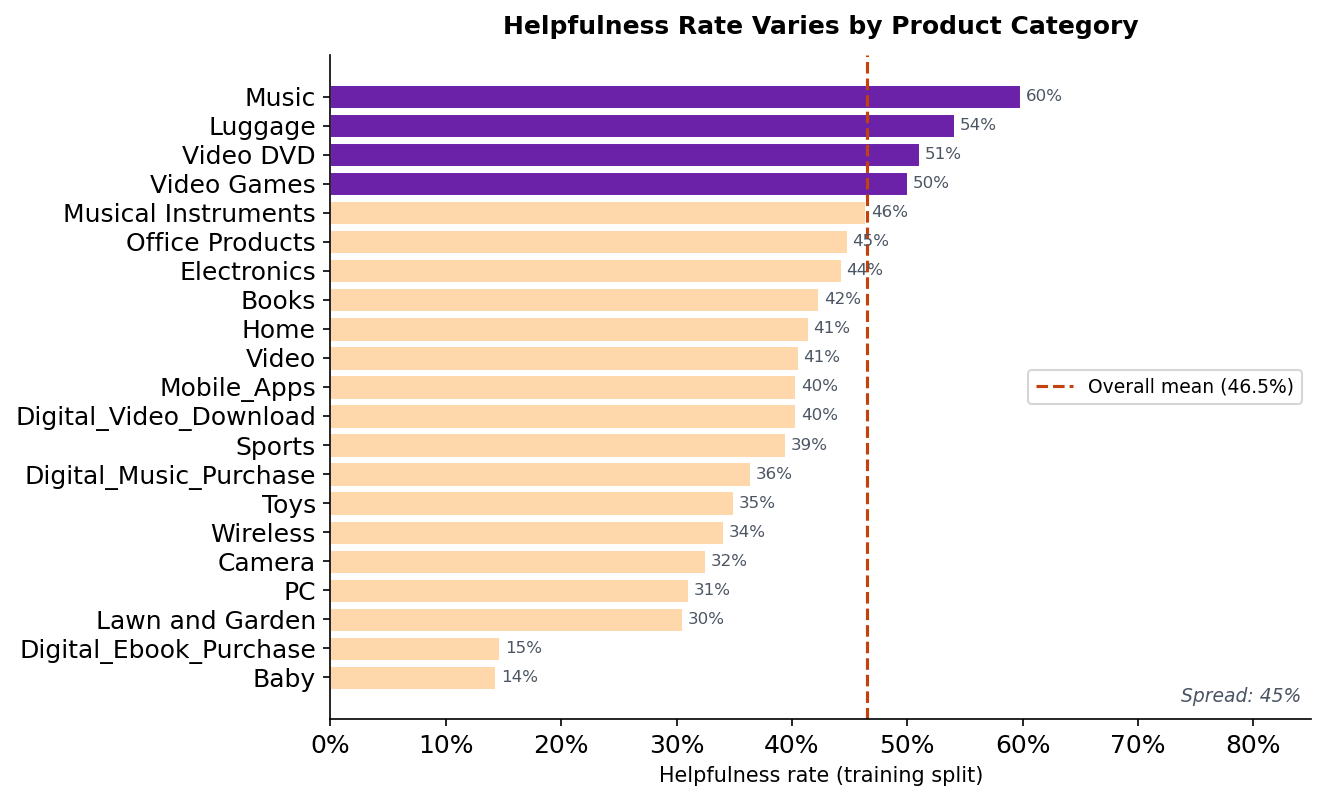

Saved eda_helpfulness_by_category.png  (spread = 45.5%)


In [17]:
# --- 6a: Helpfulness rate by product category ---
import json as _json, glob as _g2

# Load data independently in case earlier cells failed
_ml = sorted(_g2.glob(os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'gold', 'ml_features_load_date=*.parquet')))[-1]
_df = pd.read_parquet(_ml)
_df['label'] = _df['label'].astype(str).map({'True': True, 'False': False})
train_eda = _df[_df['dataset_split'] == 'train'].copy()

with open(os.path.join(os.path.dirname(os.getcwd()), '..', 'reviews (copy)', 'category.json')) as f:
    cat_map = {c['id']: c['name'] for c in _json.load(f)}

cat_stats = (
    train_eda.groupby('product_category_id')['label']
    .agg(helpful_rate='mean', n='count')
    .reset_index()
)
cat_stats = cat_stats[cat_stats['n'] >= 20].copy()
cat_stats['category'] = cat_stats['product_category_id'].map(cat_map).fillna('Other')
cat_stats = cat_stats.sort_values('helpful_rate')

baseline_eda = train_eda['label'].mean()

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = [PURPLE if r >= baseline_eda else LIGHT_ORANGE for r in cat_stats['helpful_rate']]
bars = ax.barh(cat_stats['category'], cat_stats['helpful_rate'], color=colors, edgecolor='white', linewidth=0.5)

ax.axvline(baseline_eda, color=DARK_ORANGE, linestyle='--', linewidth=1.5, label=f'Overall mean ({baseline_eda:.1%})')

for bar, rate in zip(bars, cat_stats['helpful_rate']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{rate:.0%}', va='center', fontsize=8, color=GREY)

ax.set_xlabel('Helpfulness rate (training split)', fontsize=10)
ax.set_title('Helpfulness Rate Varies by Product Category', fontsize=12, fontweight='bold', pad=10)
ax.set_xlim(0, 0.85)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(fontsize=9)

spread = cat_stats['helpful_rate'].max() - cat_stats['helpful_rate'].min()
baseline = baseline_eda
ax.text(0.99, 0.02, f'Spread: {spread:.0%}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=9, color=GREY, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_helpfulness_by_category.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved eda_helpfulness_by_category.png  (spread = {spread:.1%})')

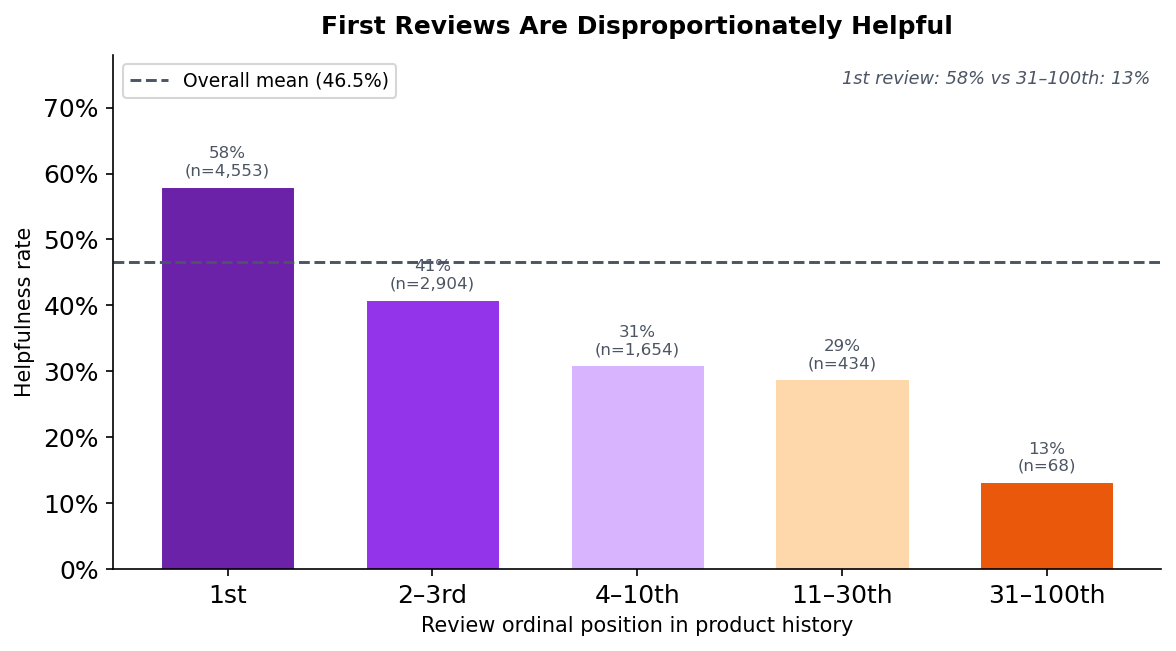

1st review helpful rate: 58.0%
31–100th review helpful rate: 13.2%
Saved eda_helpfulness_by_rank.png


In [18]:
# --- 6b: Helpfulness rate by review ordinal position in product history ---
import glob as _g3

# Load data independently in case earlier cells failed
_ml2 = sorted(_g3.glob(os.path.join(os.path.dirname(os.getcwd()), '..', 'data', 'gold', 'ml_features_load_date=*.parquet')))[-1]
_df2 = pd.read_parquet(_ml2)
_df2['label'] = _df2['label'].astype(str).map({'True': True, 'False': False})
train_eda2 = _df2[_df2['dataset_split'] == 'train'].copy()
baseline_eda2 = train_eda2['label'].mean()

rank_bins   = [0, 1, 3, 10, 30, 100, 9999]
rank_labels = ['1st', '2–3rd', '4–10th', '11–30th', '31–100th', '100+']

train_eda2['rank_bin'] = pd.cut(
    train_eda2['review_relative_rank'],
    bins=rank_bins,
    labels=rank_labels,
    right=True
)

rank_stats = (
    train_eda2.groupby('rank_bin', observed=True)['label']
    .agg(helpful_rate='mean', n='count')
    .reset_index()
)

# Colour gradient: early = purple (high), late = orange (low)
palette_rank = [PURPLE, MID_PURPLE, LIGHT_PURPLE, LIGHT_ORANGE, MID_ORANGE, DARK_ORANGE][:len(rank_stats)]

fig, ax = plt.subplots(figsize=(8, 4.5))

bars = ax.bar(rank_stats['rank_bin'], rank_stats['helpful_rate'],
              color=palette_rank, edgecolor='white', linewidth=0.5, width=0.65)

ax.axhline(baseline_eda2, color=GREY, linestyle='--', linewidth=1.4, label=f'Overall mean ({baseline_eda2:.1%})')

for bar, row in zip(bars, rank_stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f'{row.helpful_rate:.0%}\n(n={row.n:,})',
            ha='center', va='bottom', fontsize=8, color=GREY)

ax.set_xlabel('Review ordinal position in product history', fontsize=10)
ax.set_ylabel('Helpfulness rate', fontsize=10)
ax.set_title('First Reviews Are Disproportionately Helpful', fontsize=12, fontweight='bold', pad=10)
ax.set_ylim(0, 0.78)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(fontsize=9)

first_rate  = rank_stats.loc[rank_stats['rank_bin'] == '1st',      'helpful_rate'].values[0]
last_rate   = rank_stats.loc[rank_stats['rank_bin'] == '31–100th', 'helpful_rate'].values[0]
ax.text(0.99, 0.97,
        f'1st review: {first_rate:.0%} vs 31–100th: {last_rate:.0%}',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=8.5, color=GREY, style='italic')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_helpfulness_by_rank.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'1st review helpful rate: {first_rate:.1%}')
print(f'31–100th review helpful rate: {last_rate:.1%}')
print('Saved eda_helpfulness_by_rank.png')